# ⚔️ Comparaison de 3 approches — Design Pattern Recommender

Ce notebook compare **3 approches** pour recommander des design patterns à partir de code Java :

| # | Approche | Description | Durée estimée (Colab T4) |
|---|----------|-------------|---------------------------|
| 1 | **TF-IDF + SVM** | Classique, rapide, interprétable | ~2 min |
| 2 | **CodeBERT fine-tuning** | Transformer spécialisé code | ~30 min |
| 3 | **LoRA fine-tuning** | CodeBERT + LoRA, économique | ~20 min |

---
**Patterns :** Singleton · Abstract Factory · Factory Method · Strategy · Observer · Adapter · Decorator · Facade

**Instructions :**
1. `Runtime` → `Change runtime type` → **GPU T4**
2. Uploader vos 8 fichiers `.jsonl` dans `/content/data/`
3. `Runtime` → `Run all`

## 0️⃣ Installation

In [7]:
!pip install -q transformers datasets accelerate peft scikit-learn seaborn
import torch
print('✅ Packages installés')
print('GPU :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else '❌ Aucun GPU — activer dans Runtime > Change runtime type')

✅ Packages installés
GPU : Tesla T4


## 1️⃣ Chargement & préparation des données (commun aux 3 approches)

In [8]:
import os, json, re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_DIR = '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)

PATTERN_FILES = {
    'Singleton':        'singleton_java_500.jsonl',
    'Abstract Factory': 'abstract_factory_java_500.jsonl',
    'Factory Method':   'factory_method_java_500.jsonl',
    'Strategy':         'strategy_java_500.jsonl',
    'Observer':         'observer_java_500.jsonl',
    'Adapter':          'adapter_java_500.jsonl',
    'Decorator':        'decorator_java_500.jsonl',
    'Facade':           'facade_java_500.jsonl',
}
LABEL2ID   = {p: i for i, p in enumerate(PATTERN_FILES)}
ID2LABEL   = {i: p for p, i in LABEL2ID.items()}
ALL_LABELS = list(PATTERN_FILES.keys())

def clean_code(code):
    """Supprime les artefacts synthétiques pour forcer le modèle à apprendre la structure."""
    code = re.sub(r'//\s*Style:.*\n', '', code)           # retire "// Style: Classic..."
    code = re.sub(r'(\b[A-Za-z][A-Za-z0-9_]*)(\d+)\b', r'\1', code)  # ConfigManager42 → ConfigManager
    code = re.sub(r'\n{3,}', '\n\n', code)
    return code.strip()

rows = []
for pattern, fname in PATTERN_FILES.items():
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print(f'  ❌ MANQUANT : {fname}')
        continue
    with open(path) as f:
        for line in f:
            rec = json.loads(line.strip())
            rows.append({'code': clean_code(rec['code']), 'label': LABEL2ID[pattern], 'pattern': pattern})
    print(f'  ✅ {pattern:22s} chargé')

df = pd.DataFrame(rows)
print(f'\n📦 Total : {len(df)} exemples | {df["pattern"].nunique()} patterns')

# Split stratifié 80 / 10 / 10
train_val, df_test = train_test_split(df, test_size=0.10, stratify=df['label'], random_state=42)
df_train, df_val   = train_test_split(train_val, test_size=0.111, stratify=train_val['label'], random_state=42)
print(f'Train : {len(df_train)}  Val : {len(df_val)}  Test : {len(df_test)}')

  ✅ Singleton              chargé
  ✅ Abstract Factory       chargé
  ✅ Factory Method         chargé
  ✅ Strategy               chargé
  ✅ Observer               chargé
  ✅ Adapter                chargé
  ✅ Decorator              chargé
  ✅ Facade                 chargé

📦 Total : 4000 exemples | 8 patterns
Train : 3200  Val : 400  Test : 400


## 🔧 Utilitaires d'évaluation (communs aux 3 approches)

In [9]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

RESULTS = {}   # stockage des résultats pour le tableau comparatif final

def evaluate_and_store(name, y_true, y_pred, train_time_sec):
    acc  = accuracy_score(y_true, y_pred)
    f1m  = f1_score(y_true, y_pred, average='macro')
    f1w  = f1_score(y_true, y_pred, average='weighted')
    RESULTS[name] = {'Accuracy': acc, 'F1 Macro': f1m, 'F1 Weighted': f1w, 'Temps (min)': round(train_time_sec/60, 1)}
    print(f'\n{'─'*55}')
    print(f'  📊 {name}')
    print(f'{'─'*55}')
    print(f'  Accuracy    : {acc*100:.2f}%')
    print(f'  F1 macro    : {f1m*100:.2f}%')
    print(f'  F1 weighted : {f1w*100:.2f}%')
    print(f'  Temps       : {train_time_sec/60:.1f} min')
    print(f'\n{classification_report(y_true, y_pred, target_names=ALL_LABELS)}')
    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[l[:8] for l in ALL_LABELS],
                yticklabels=[l[:8] for l in ALL_LABELS])
    plt.title(f'Matrice de Confusion — {name}', fontsize=13)
    plt.ylabel('Vrai'); plt.xlabel('Prédit')
    plt.xticks(rotation=45, ha='right'); plt.tight_layout()
    plt.savefig(f'/content/cm_{name.replace(" ","_")}.png', dpi=130)
    plt.show()

print('✅ Utilitaires prêts')

✅ Utilitaires prêts


---
# 🥇 Approche 1 — TF-IDF + SVM

**Principe :** Vectoriser le code source avec TF-IDF (tokens de code comme features),  
puis entraîner un SVM linéaire.

**Avantages :** Très rapide (~2 min), pas de GPU nécessaire, très interprétable.  
**Limites :** Ne comprend pas la structure syntaxique du code.

🚀 Entraînement TF-IDF + SVM...

───────────────────────────────────────────────────────
  📊 TF-IDF + SVM
───────────────────────────────────────────────────────
  Accuracy    : 100.00%
  F1 macro    : 100.00%
  F1 weighted : 100.00%
  Temps       : 0.0 min

                  precision    recall  f1-score   support

       Singleton       1.00      1.00      1.00        50
Abstract Factory       1.00      1.00      1.00        50
  Factory Method       1.00      1.00      1.00        50
        Strategy       1.00      1.00      1.00        50
        Observer       1.00      1.00      1.00        50
         Adapter       1.00      1.00      1.00        50
       Decorator       1.00      1.00      1.00        50
          Facade       1.00      1.00      1.00        50

        accuracy                           1.00       400
       macro avg       1.00      1.00      1.00       400
    weighted avg       1.00      1.00      1.00       400



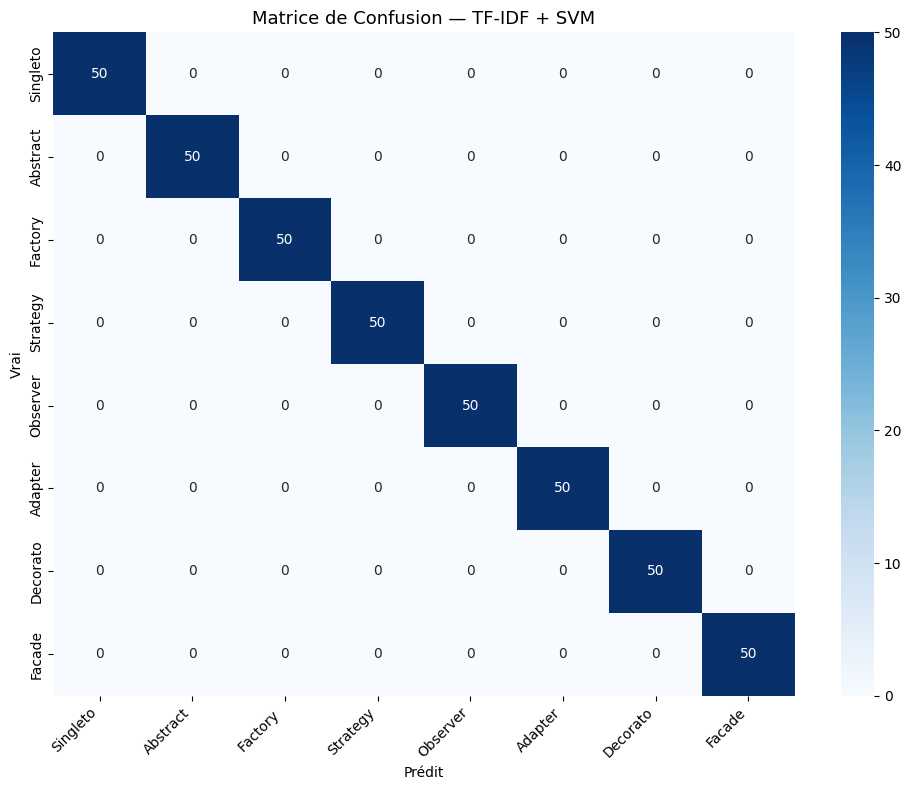


🔍 Top 10 features TF-IDF par pattern :
  Singleton             : instance, public enum, instance private, instance private string, private string, enum, int, getinstance return, private, public class
  Abstract Factory      : void create, void build, build, create interface, void create interface, void build enum, build enum, create system out, create system, void create system
  Factory Method        : p, create return, create return system, void operation, operation, return new, public void operation, implements, default, default void
  Strategy              : strategy, strategy public, strategy public void, strategy this strategy, this strategy strategy, strategy strategy public, strategy this, strategy strategy, this strategy, void execute string
  Observer              : o, observers, arraylist, list, o observers, add, java util, util, java, consumer
  Adapter               : input, adaptee, result input class, result, string input, result input, string input return, input return

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import CalibratedClassifierCV

print('🚀 Entraînement TF-IDF + SVM...')
t0 = time.time()

# Pipeline : TF-IDF sur les tokens du code (ngrams 1-3) + SVM linéaire
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer    = 'word',
        token_pattern = r'[a-zA-Z_][a-zA-Z0-9_]*',  # tokens Java (identifiants)
        ngram_range = (1, 3),
        max_features = 50_000,
        sublinear_tf = True,                         # log(tf) — réduit l'effet des mots fréquents
    )),
    ('clf', CalibratedClassifierCV(LinearSVC(max_iter=5000, C=1.0), cv=3)),
])

svm_pipeline.fit(df_train['code'], df_train['label'])
svm_time = time.time() - t0

svm_preds = svm_pipeline.predict(df_test['code'])
evaluate_and_store('TF-IDF + SVM', df_test['label'].values, svm_preds, svm_time)

# Afficher les features les plus importantes par pattern
print('\n🔍 Top 10 features TF-IDF par pattern :')
feature_names = svm_pipeline.named_steps['tfidf'].get_feature_names_out()

# Accès compatible toutes versions sklearn
calibrated = svm_pipeline.named_steps['clf']
base_clf = calibrated.calibrated_classifiers_[0].estimator  # sklearn >= 1.2
# Si erreur → essaie : .base_estimator   (sklearn < 1.2)

if hasattr(base_clf, 'coef_'):
    for i, pattern in ID2LABEL.items():
        top10 = np.argsort(base_clf.coef_[i])[-10:][::-1]
        print(f'  {pattern:22s}: {", ".join(feature_names[top10])}')
else:
    print('  ⚠️  coef_ non disponible sur ce classifieur.')

---
# 🥈 Approche 2 — Fine-tuning CodeBERT

**Principe :** Fine-tuner `microsoft/codebert-base` (125M params) sur notre dataset.  
Entraîner **toutes** les couches du transformer.

**Avantages :** Comprend la syntaxe et la sémantique du code, meilleure généralisation.  
**Limites :** ~30 min sur Colab T4, utilise ~6 GB de VRAM.

In [11]:
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)

MODEL_NAME = 'microsoft/codebert-base'
MAX_LEN    = 512

print(f'📥 Chargement de {MODEL_NAME}...')
cb_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
cb_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=8,
    id2label=ID2LABEL, label2id=LABEL2ID,
    ignore_mismatched_sizes=True
)
print(f'✅ Modèle chargé — {sum(p.numel() for p in cb_model.parameters())/1e6:.1f}M paramètres')

def make_hf_datasets(df_tr, df_v, df_te):
    def to_hf(df): return Dataset.from_dict({'code': df['code'].tolist(), 'label': df['label'].tolist()})
    raw = DatasetDict({'train': to_hf(df_tr), 'val': to_hf(df_v), 'test': to_hf(df_te)})
    def tok(batch): return cb_tokenizer(batch['code'], padding='max_length', truncation=True, max_length=MAX_LEN)
    tokenized = raw.map(tok, batched=True, batch_size=64)
    tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
    return tokenized

print('🔤 Tokenisation...')
cb_data = make_hf_datasets(df_train, df_val, df_test)
print('✅ Tokenisation terminée')

📥 Chargement de microsoft/codebert-base...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

✅ Modèle chargé — 124.7M paramètres
🔤 Tokenisation...


Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

✅ Tokenisation terminée


🚀 Entraînement CodeBERT (full fine-tuning)...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.017989,0.006960,1.000000,1.000000
2,0.004395,0.002331,1.000000,1.000000
3,0.002753,0.001521,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


───────────────────────────────────────────────────────
  📊 CodeBERT Fine-tuning
───────────────────────────────────────────────────────
  Accuracy    : 100.00%
  F1 macro    : 100.00%
  F1 weighted : 100.00%
  Temps       : 4.9 min

                  precision    recall  f1-score   support

       Singleton       1.00      1.00      1.00        50
Abstract Factory       1.00      1.00      1.00        50
  Factory Method       1.00      1.00      1.00        50
        Strategy       1.00      1.00      1.00        50
        Observer       1.00      1.00      1.00        50
         Adapter       1.00      1.00      1.00        50
       Decorator       1.00      1.00      1.00        50
          Facade       1.00      1.00      1.00        50

        accuracy                           1.00       400
       macro avg       1.00      1.00      1.00       400
    weighted avg       1.00      1.00      1.00       400



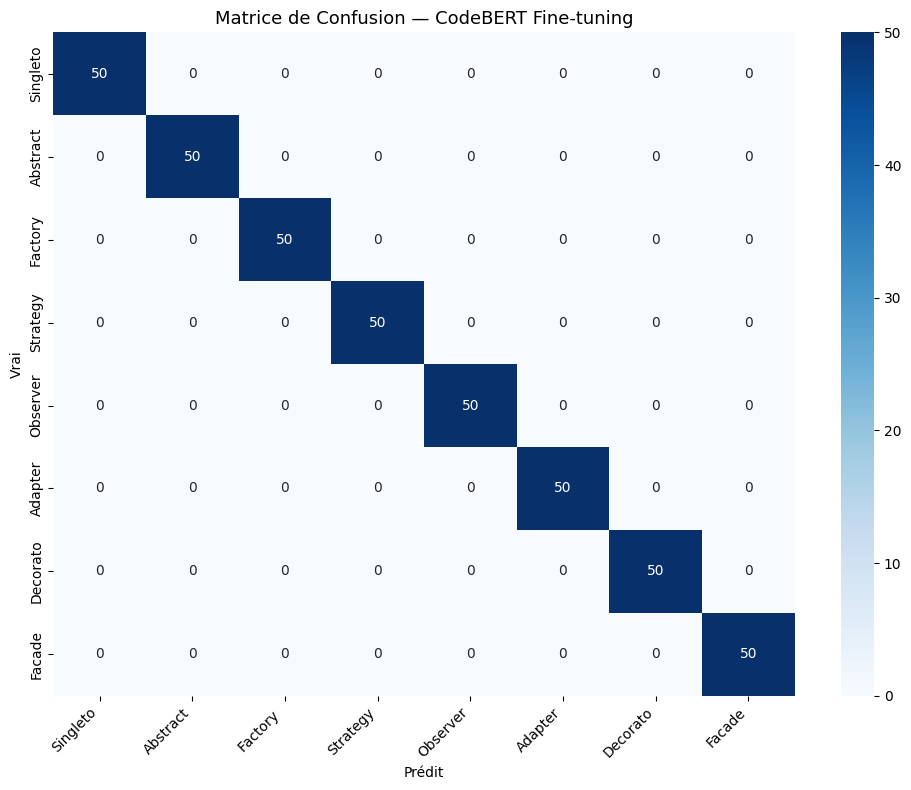

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Modèle CodeBERT sauvegardé → /content/model_codebert


In [12]:
def compute_metrics_hf(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

# 1. warmup_ratio → warmup_steps
# 2. tokenizer → processing_class  (renommé dans transformers récent)

cb_args = TrainingArguments(
    output_dir                  = '/content/codebert_checkpoints',
    num_train_epochs            = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_steps                = 100,       # ← remplace warmup_ratio
    lr_scheduler_type           = 'cosine',
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    logging_steps               = 50,
    report_to                   = 'none',
    fp16                        = torch.cuda.is_available(),
    dataloader_num_workers      = 0,
    seed                        = 42,
)

cb_trainer = Trainer(
    model              = cb_model,
    args               = cb_args,
    train_dataset      = cb_data['train'],
    eval_dataset       = cb_data['val'],
    processing_class   = cb_tokenizer,       # ← remplace tokenizer
    compute_metrics    = compute_metrics_hf,
    callbacks          = [EarlyStoppingCallback(early_stopping_patience=2)],
)
print('🚀 Entraînement CodeBERT (full fine-tuning)...')
t0 = time.time()
cb_trainer.train()
cb_time = time.time() - t0

cb_preds_out = cb_trainer.predict(cb_data['test'])
cb_preds     = np.argmax(cb_preds_out.predictions, axis=-1)
evaluate_and_store('CodeBERT Fine-tuning', df_test['label'].values, cb_preds, cb_time)

# Sauvegarder
cb_trainer.save_model('/content/model_codebert')
cb_tokenizer.save_pretrained('/content/model_codebert')
print('✅ Modèle CodeBERT sauvegardé → /content/model_codebert')

---
# 🥉 Approche 3 — LoRA Fine-tuning (PEFT)

**Principe :** Fine-tuner CodeBERT avec **LoRA** (Low-Rank Adaptation).  
Au lieu de modifier tous les poids, on entraîne seulement de **petites matrices de rang faible**  
injectées dans les couches d'attention → **~1% des paramètres** entraînés.

**Avantages :** Moins de VRAM (~3 GB), plus rapide, résultats proches du full fine-tuning.  
**Limites :** Légèrement moins précis que le full fine-tuning sur datasets petits.

```
LoRA : W_new = W_original + (A × B)   où rang(A×B) << rang(W)
       W_original est gelé, seuls A et B sont entraînés
```

In [13]:
from peft import LoraConfig, get_peft_model, TaskType
from transformers import AutoModelForSequenceClassification, AutoTokenizer

print('📥 Chargement du modèle de base pour LoRA...')
lora_base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=8,
    id2label=ID2LABEL, label2id=LABEL2ID,
    ignore_mismatched_sizes=True
)
lora_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Configuration LoRA
lora_config = LoraConfig(
    task_type    = TaskType.SEQ_CLS,   # classification de séquence
    r            = 16,                 # rang des matrices low-rank
    lora_alpha   = 32,                 # scaling factor (alpha/r = 2)
    lora_dropout = 0.1,
    target_modules = ['query', 'value'],  # couches d'attention ciblées
    bias         = 'none',
)

lora_model = get_peft_model(lora_base, lora_config)

# Afficher les paramètres entraînables
total_params     = sum(p.numel() for p in lora_model.parameters())
trainable_params = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
print(f'\n  Paramètres totaux     : {total_params/1e6:.1f}M')
print(f'  Paramètres entraînés  : {trainable_params/1e6:.2f}M  ({trainable_params/total_params*100:.2f}%)')
print(f'  ➜ LoRA entraîne seulement {trainable_params/total_params*100:.1f}% des poids !')

📥 Chargement du modèle de base pour LoRA...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Paramètres totaux     : 125.8M
  Paramètres entraînés  : 1.19M  (0.94%)
  ➜ LoRA entraîne seulement 0.9% des poids !


🔤 Tokenisation LoRA...


Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

🚀 Entraînement LoRA...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.003036,0.000543,1.000000,1.000000
2,0.000465,0.000176,1.000000,1.000000
3,0.000250,0.000099,1.000000,1.000000
4,0.000231,0.000072,1.000000,1.000000



───────────────────────────────────────────────────────
  📊 LoRA Fine-tuning
───────────────────────────────────────────────────────
  Accuracy    : 100.00%
  F1 macro    : 100.00%
  F1 weighted : 100.00%
  Temps       : 4.9 min

                  precision    recall  f1-score   support

       Singleton       1.00      1.00      1.00        50
Abstract Factory       1.00      1.00      1.00        50
  Factory Method       1.00      1.00      1.00        50
        Strategy       1.00      1.00      1.00        50
        Observer       1.00      1.00      1.00        50
         Adapter       1.00      1.00      1.00        50
       Decorator       1.00      1.00      1.00        50
          Facade       1.00      1.00      1.00        50

        accuracy                           1.00       400
       macro avg       1.00      1.00      1.00       400
    weighted avg       1.00      1.00      1.00       400



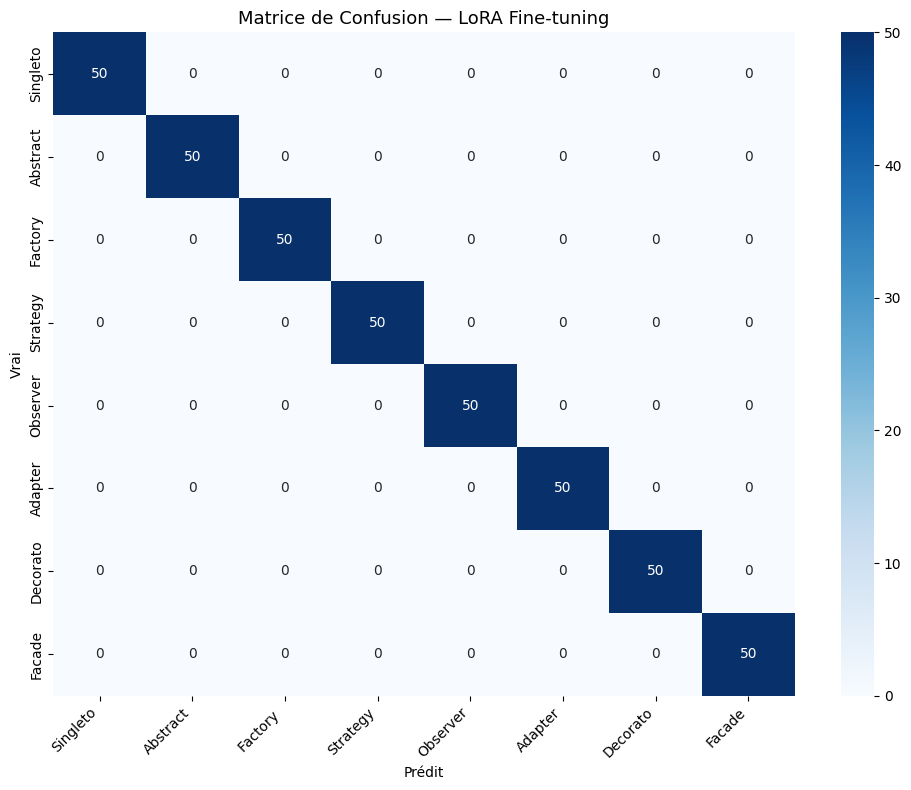

✅ Adaptateurs LoRA sauvegardés → /content/model_lora


In [14]:
# Retokeniser avec le tokenizer LoRA (identique à CodeBERT ici)
def make_lora_datasets(df_tr, df_v, df_te):
    def to_hf(df): return Dataset.from_dict({'code': df['code'].tolist(), 'label': df['label'].tolist()})
    raw = DatasetDict({'train': to_hf(df_tr), 'val': to_hf(df_v), 'test': to_hf(df_te)})
    def tok(batch): return lora_tokenizer(batch['code'], padding='max_length', truncation=True, max_length=MAX_LEN)
    tokenized = raw.map(tok, batched=True, batch_size=64)
    tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
    return tokenized

print('🔤 Tokenisation LoRA...')
lora_data = make_lora_datasets(df_train, df_val, df_test)

lora_args = TrainingArguments(
    output_dir                  = '/content/lora_checkpoints',
    num_train_epochs            = 8,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate               = 3e-4,
    weight_decay                = 0.01,
    warmup_steps                = 100,       # ← warmup_ratio → warmup_steps
    lr_scheduler_type           = 'cosine',
    eval_strategy               = 'epoch',   # ← evaluation_strategy → eval_strategy
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    logging_steps               = 50,
    report_to                   = 'none',
    fp16                        = torch.cuda.is_available(),
    dataloader_num_workers      = 0,
    seed                        = 42,
)

lora_trainer = Trainer(
    model            = lora_model,
    args             = lora_args,
    train_dataset    = lora_data['train'],
    eval_dataset     = lora_data['val'],
    processing_class = lora_tokenizer,       # ← tokenizer → processing_class
    compute_metrics  = compute_metrics_hf,
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=3)],
)

print('🚀 Entraînement LoRA...')
t0 = time.time()
lora_trainer.train()
lora_time = time.time() - t0

lora_preds_out = lora_trainer.predict(lora_data['test'])
lora_preds     = np.argmax(lora_preds_out.predictions, axis=-1)
evaluate_and_store('LoRA Fine-tuning', df_test['label'].values, lora_preds, lora_time)

# Sauvegarder les adaptateurs LoRA seulement (très léger !)
lora_model.save_pretrained('/content/model_lora')
lora_tokenizer.save_pretrained('/content/model_lora')
print('✅ Adaptateurs LoRA sauvegardés → /content/model_lora')

---
# 📊 Tableau comparatif final


═════════════════════════════════════════════════════════════════
  🏆  COMPARAISON DES 3 APPROCHES — TEST SET
═════════════════════════════════════════════════════════════════
                     Accuracy F1 Macro F1 Weighted  Temps (min)
TF-IDF + SVM          100.00%  100.00%     100.00%          0.0
CodeBERT Fine-tuning  100.00%  100.00%     100.00%          4.9
LoRA Fine-tuning      100.00%  100.00%     100.00%          4.9
═════════════════════════════════════════════════════════════════


/tmp/ipykernel_4784/2392689363.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results_df[['Accuracy', 'F1 Macro', 'F1 Weighted']] = results_df[['Accuracy', 'F1 Macro', 'F1 Weighted']].applymap(lambda x: f'{x*100:.2f}%')
/tmp/ipykernel_4784/2392689363.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(raw.index, rotation=20, ha='right', fontsize=10)
/tmp/ipykernel_4784/2392689363.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(raw.index, rotation=20, ha='right', fontsize=10)
/tmp/ipykernel_4784/2392689363.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(raw.index, rotation=20, ha='right', fontsize=10)


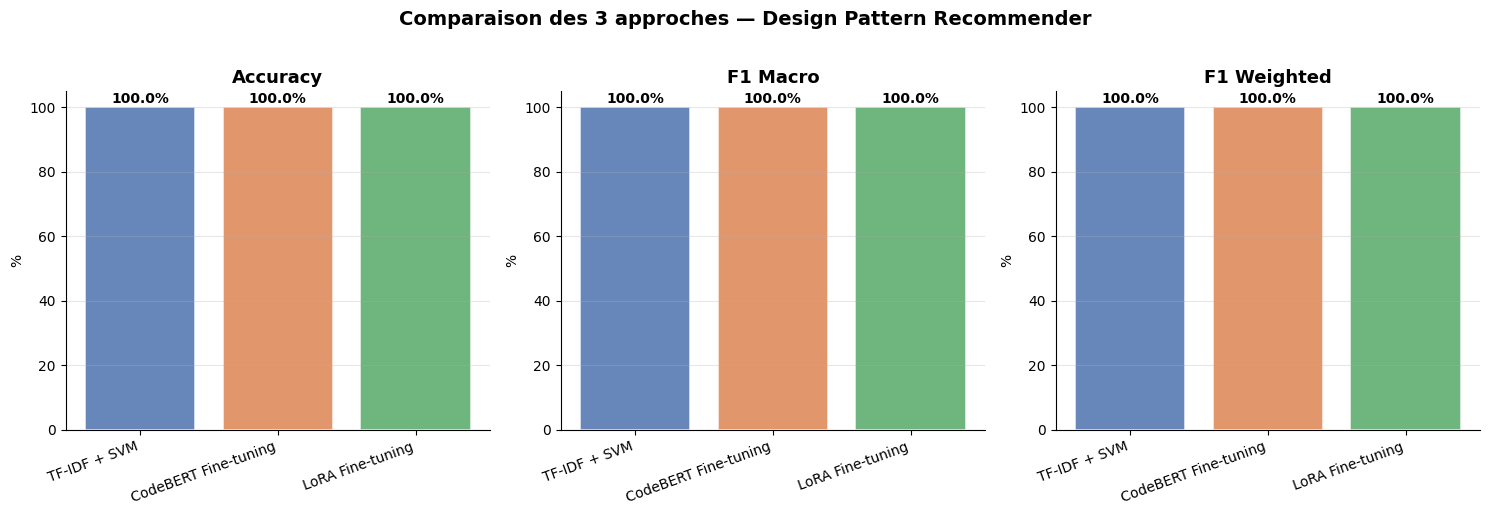

✅ Graphique → /content/comparison.png


In [15]:
results_df = pd.DataFrame(RESULTS).T
results_df = results_df.sort_values('F1 Macro', ascending=False)
results_df[['Accuracy', 'F1 Macro', 'F1 Weighted']] = results_df[['Accuracy', 'F1 Macro', 'F1 Weighted']].applymap(lambda x: f'{x*100:.2f}%')

print('\n' + '═'*65)
print('  🏆  COMPARAISON DES 3 APPROCHES — TEST SET')
print('═'*65)
print(results_df.to_string())
print('═'*65)

# Graphique comparatif
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
raw = pd.DataFrame(RESULTS).T
metrics = ['Accuracy', 'F1 Macro', 'F1 Weighted']
colors  = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(raw.index, raw[metric] * 100, color=colors, alpha=0.85, edgecolor='white', linewidth=1.2)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel('%')
    ax.set_ylim(0, 105)
    ax.set_xticklabels(raw.index, rotation=20, ha='right', fontsize=10)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Comparaison des 3 approches — Design Pattern Recommender', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique → /content/comparison.png')

---
# 🎯 Inférence unifiée — tester les 3 modèles sur du nouveau code

In [16]:
from peft import PeftModel

def predict_svm(code):
    probs  = svm_pipeline.predict_proba([clean_code(code)])[0]
    top3   = np.argsort(probs)[::-1][:3]
    return [(ID2LABEL[i], probs[i]) for i in top3]

def predict_transformer(model, tokenizer_, code, device='cuda'):
    model.eval()
    enc = tokenizer_(clean_code(code), padding='max_length', truncation=True, max_length=512, return_tensors='pt')
    enc = {k: v.to(device if torch.cuda.is_available() else 'cpu') for k, v in enc.items()}
    with torch.no_grad():
        probs = torch.softmax(model(**enc).logits[0], dim=-1).cpu().numpy()
    top3 = np.argsort(probs)[::-1][:3]
    return [(ID2LABEL[i], probs[i]) for i in top3]

def show_all_predictions(code, label=None):
    print('\n' + '═'*60)
    if label: print(f'  ✅ Vrai pattern : {label}')
    print(f'  Code : {code[:120].strip()}...' if len(code) > 120 else f'  Code : {code.strip()}')
    print('─'*60)
    for name, preds_fn in [
        ('TF-IDF + SVM',        lambda: predict_svm(code)),
        ('CodeBERT',            lambda: predict_transformer(cb_model, cb_tokenizer, code)),
        ('LoRA',                lambda: predict_transformer(lora_model, lora_tokenizer, code)),
    ]:
        top = preds_fn()
        best = top[0]
        bar  = '█' * int(best[1] * 25)
        print(f'  {name:22s}→  {best[0]:22s}  {bar:<25}  {best[1]*100:.1f}%')
        for pattern, score in top[1:]:
            print(f'  {"":22s}   {pattern:22s}  {" "*25}  {score*100:.1f}%')
        print()
    print('═'*60)

# ─── Tests ───────────────────────────────────────────────
show_all_predictions('''
public class DatabaseConnection {
    private static volatile DatabaseConnection instance;
    private DatabaseConnection() {}
    public static DatabaseConnection getInstance() {
        if (instance == null) {
            synchronized (DatabaseConnection.class) {
                if (instance == null) instance = new DatabaseConnection();
            }
        }
        return instance;
    }
}
''', label='Singleton')

show_all_predictions('''
interface SortStrategy { void sort(int[] data); }
class BubbleSort implements SortStrategy {
    public void sort(int[] data) { /* bubble */ }
}
class QuickSort implements SortStrategy {
    public void sort(int[] data) { /* quick */ }
}
class Sorter {
    private SortStrategy strategy;
    public Sorter(SortStrategy s) { this.strategy = s; }
    public void setStrategy(SortStrategy s) { this.strategy = s; }
    public void sort(int[] data) { strategy.sort(data); }
}
''', label='Strategy')

show_all_predictions('''
interface Logger { void log(String msg); }
class ConsoleLogger implements Logger {
    public void log(String msg) { System.out.println(msg); }
}
abstract class LoggerDecorator implements Logger {
    protected final Logger wrapped;
    public LoggerDecorator(Logger w) { this.wrapped = w; }
    public void log(String msg) { wrapped.log(msg); }
}
class TimestampLogger extends LoggerDecorator {
    public TimestampLogger(Logger w) { super(w); }
    public void log(String msg) { super.log("[TS] " + msg); }
}
''', label='Decorator')


════════════════════════════════════════════════════════════
  ✅ Vrai pattern : Singleton
  Code : public class DatabaseConnection {
    private static volatile DatabaseConnection instance;
    private DatabaseConnecti...
────────────────────────────────────────────────────────────
  TF-IDF + SVM          →  Singleton               ████████████████████████   99.7%
                           Decorator                                          0.1%
                           Strategy                                           0.0%

  CodeBERT              →  Singleton               ████████████████████████   99.3%
                           Factory Method                                     0.1%
                           Adapter                                            0.1%

  LoRA                  →  Singleton               ████████████████████████   100.0%
                           Factory Method                                     0.0%
                           Adapter            

---
# 💾 Sauvegarde & téléchargement

In [17]:
import shutil, pickle

# Sauvegarder le pipeline SVM
with open('/content/model_svm.pkl', 'wb') as f:
    pickle.dump(svm_pipeline, f)

# Zipper tous les modèles
shutil.make_archive('/content/model_codebert_zip', 'zip', '/content/model_codebert')
shutil.make_archive('/content/model_lora_zip',     'zip', '/content/model_lora')

# Sauvegarder le tableau comparatif
pd.DataFrame(RESULTS).T.to_csv('/content/comparison_results.csv')

print('✅ Fichiers à télécharger depuis le panneau Fichiers (📁) :')
print('   /content/model_svm.pkl              ← SVM pipeline')
print('   /content/model_codebert_zip.zip     ← CodeBERT fine-tuned')
print('   /content/model_lora_zip.zip         ← LoRA adaptateurs (léger)')
print('   /content/comparison_results.csv     ← Tableau comparatif')
print('   /content/comparison.png             ← Graphique')

✅ Fichiers à télécharger depuis le panneau Fichiers (📁) :
   /content/model_svm.pkl              ← SVM pipeline
   /content/model_codebert_zip.zip     ← CodeBERT fine-tuned
   /content/model_lora_zip.zip         ← LoRA adaptateurs (léger)
   /content/comparison_results.csv     ← Tableau comparatif
   /content/comparison.png             ← Graphique


---
# 📋 Guide de décision — Quelle approche choisir ?

| Critère | TF-IDF + SVM | CodeBERT | LoRA |
|---------|:---:|:---:|:---:|
| Précision (F1) | ⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ |
| Vitesse d'entraînement | ⭐⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐ |
| VRAM nécessaire | ❌ | ~6 GB | ~3 GB |
| Généralisation code réel | ⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ |
| Interprétabilité | ⭐⭐⭐⭐⭐ | ⭐ | ⭐ |
| Taille du modèle | ~10 MB | ~500 MB | ~10 MB |

### ✅ Recommandations
- **Prototype rapide / pas de GPU** → TF-IDF + SVM
- **Meilleure précision absolue** → CodeBERT fine-tuning
- **Bon compromis vitesse/précision** → LoRA (recommandé pour production)
- **Déploiement léger** → LoRA (sauvegarder uniquement les adaptateurs ~10 MB)